In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# --- Activation functions ---
x = torch.linspace(-3, 3, 7)
print(f"Input:  {x.tolist()}")
print(f"ReLU:   {F.relu(x).tolist()}")        # max(0, x) — zeros negatives
print(f"GELU:   {F.gelu(x).tolist()}")        # smooth ReLU — used in transformers
print(f"Sigmoid:{torch.sigmoid(x).tolist()}")  # 1/(1+e^-x) — squashes to [0,1]
print(f"Tanh:   {torch.tanh(x).tolist()}")     # squashes to [-1,1]

Input:  [-3.0, -2.0, -1.0, 0.0, 1.0, 2.0, 3.0]
ReLU:   [0.0, 0.0, 0.0, 0.0, 1.0, 2.0, 3.0]
GELU:   [-0.004049867391586304, -0.045500099658966064, -0.1586552858352661, 0.0, 0.8413447141647339, 1.9544999599456787, 2.995950222015381]
Sigmoid:[0.04742587357759476, 0.11920291930437088, 0.2689414322376251, 0.5, 0.7310585975646973, 0.8807970285415649, 0.9525741338729858]
Tanh:   [-0.9950547814369202, -0.9640275835990906, -0.7615941762924194, 0.0, 0.7615941762924194, 0.9640275835990906, 0.9950547814369202]


In [2]:
import matplotlib.pyplot as plt

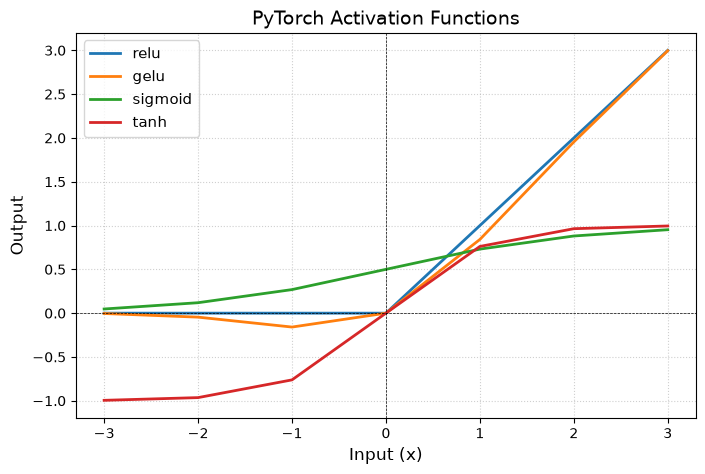

In [4]:
functions = [F.relu, F.gelu, torch.sigmoid, torch.tanh]

plt.figure(figsize=(8, 5))
for func in functions:
    plt.plot(x.numpy(), func(x).numpy(), label=func.__name__, linewidth=2)

plt.title("PyTorch Activation Functions", fontsize=14)
plt.xlabel("Input (x)", fontsize=12)
plt.ylabel("Output", fontsize=12)
plt.axhline(0, color='black', linewidth=0.5, linestyle='--')
plt.axvline(0, color='black', linewidth=0.5, linestyle='--')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(fontsize=11)

plt.show()

In [3]:
# --- Loss functions ---
# MSE (regression): bike delivery time prediction
pred = torch.tensor([8.0, 15.0, 25.0])
target = torch.tensor([7.0, 16.0, 22.0])
mse_loss = F.mse_loss(pred, target)
print(f"\nMSE loss: {mse_loss.item():.4f}")  # ((1+1+9)/3) = 3.667

# CrossEntropy (classification): MNIST digit classification
logits = torch.tensor([[0.1, 0.3, 5.0], [8.0, 0.2, 0.1]])  # [batch=2, classes=3]
labels = torch.tensor([2, 0])                               # correct class indices
ce_loss = F.cross_entropy(logits, labels)
print(f"CrossEntropy loss: {ce_loss.item():.4f}")


MSE loss: 3.6667
CrossEntropy loss: 0.0086


In [4]:
# --- Linear layer internals ---
linear = nn.Linear(4, 2)
print(f"\nLinear weight shape: {linear.weight.shape}")  # [2, 4] (out, in)
print(f"Linear bias shape: {linear.bias.shape}")        # [2]

# y = xW^T + b
sample = torch.tensor([1.0, 2.0, 3.0, 4.0])
output = linear(sample)
manual = torch.matmul(linear.weight, sample) + linear.bias
print(f"Output matches manual: {torch.allclose(output, manual)}")  # True


Linear weight shape: torch.Size([2, 4])
Linear bias shape: torch.Size([2])
Output matches manual: True


In [5]:
# --- Dropout (regularization during training) ---
dropout = nn.Dropout(p=0.5)
data = torch.ones(1, 10)
model_train = dropout(data)    # randomly zeros ~50% and scales rest by 2
dropout.eval()                  # switch to inference mode
model_eval = dropout(data)     # identity — no dropout in eval
print(f"\nDropout train: {model_train}")  # some zeros
print(f"Dropout eval: {model_eval}")      # all ones


Dropout train: tensor([[2., 0., 2., 2., 2., 2., 0., 0., 0., 0.]])
Dropout eval: tensor([[1., 1., 1., 1., 1., 1., 1., 1., 1., 1.]])
